# Phase III: Envelope optimization integrated into surroundings

**Building:** H Building · **Model:** `models/h_envelope_rb.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/h_envelope_rb_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with nine envelope and natural-ventilation variables. Run this notebook from its own folder (paths are relative to `notebooks/`).

## Envelope optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation Model

In [2]:
building = ef.get_building('../models/h_envelope_rb.idf') # Loading the E+ model;

### Variables

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_north",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - North Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_south",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - South Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_east",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - East Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_west",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - West Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_roof",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Ext mortar",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Fibercement tile",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="WINDOWMATERIAL:GLAZING",   # Class of E+;
                    object_name="Clear 3mm",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='Glazing - Thickness',
                value_descriptor=RangeParameter(min_val=0.003, max_val=0.01)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="SCHEDULE:COMPACT",             # Class of E+;
                    object_name="VN_19",    # Object name;
                    field_name="Field 4", # Object field;
                ),
                name='AFN - Setpoint',
                value_descriptor=RangeParameter(min_val=18, max_val=25)      # Range
                )
            )


### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=500, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

1 day, 7:57:32.115102


### Results

In [6]:
results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.029572,0.000471,0.004137,0.011684,0.004775,0.234976,0.204948,0.003664,22.006651,8.923475e+10,6.212759e+10,0,True
1,0.136270,0.140995,0.146975,0.129710,0.145200,0.745369,0.660159,0.009196,24.578916,1.884537e+11,1.210992e+09,0,True
2,0.030074,0.008143,0.006608,0.016324,0.004163,0.235401,0.245779,0.004713,22.000162,9.355350e+10,5.198308e+10,0,True
3,0.118483,0.131481,0.149980,0.110070,0.148820,0.577416,0.639633,0.009050,24.992292,1.828757e+11,1.526643e+09,0,True
4,0.148709,0.091330,0.149211,0.146155,0.131887,0.552946,0.791371,0.009837,22.882830,1.496495e+11,1.563855e+09,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.133599,0.140530,0.144890,0.137559,0.144134,0.745369,0.620222,0.005472,24.710749,1.869471e+11,1.307055e+09,0,False
96,0.019518,0.004010,0.003232,0.000768,0.017108,0.262035,0.265738,0.004504,21.082362,9.333667e+10,6.352264e+10,0,False
97,0.130345,0.146414,0.111740,0.135178,0.139333,0.417279,0.742977,0.009195,24.024457,1.807274e+11,1.573497e+09,0,False
98,0.009508,0.066795,0.023850,0.003822,0.045674,0.280122,0.201208,0.005428,21.505290,9.969061e+10,3.433909e+10,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/876.15)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/876.15)

results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.029572,0.000471,0.004137,0.011684,0.004775,0.234976,0.204948,0.003664,22.006651,28.291308,19.697158,0,True
1,0.136270,0.140995,0.146975,0.129710,0.145200,0.745369,0.660159,0.009196,24.578916,59.748055,0.383937,0,True
2,0.030074,0.008143,0.006608,0.016324,0.004163,0.235401,0.245779,0.004713,22.000162,29.660543,16.480904,0,True
3,0.118483,0.131481,0.149980,0.110070,0.148820,0.577416,0.639633,0.009050,24.992292,57.979587,0.484012,0,True
4,0.148709,0.091330,0.149211,0.146155,0.131887,0.552946,0.791371,0.009837,22.882830,47.445433,0.495810,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.133599,0.140530,0.144890,0.137559,0.144134,0.745369,0.620222,0.005472,24.710749,59.270378,0.414393,0,False
96,0.019518,0.004010,0.003232,0.000768,0.017108,0.262035,0.265738,0.004504,21.082362,29.591795,20.139448,0,False
97,0.130345,0.146414,0.111740,0.135178,0.139333,0.417279,0.742977,0.009195,24.024457,57.298484,0.498867,0,False
98,0.009508,0.066795,0.023850,0.003822,0.045674,0.280122,0.201208,0.005428,21.505290,31.606273,10.886988,0,False


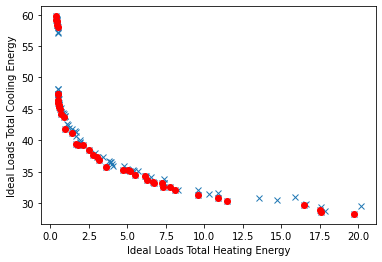

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/h_envelope_rb_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

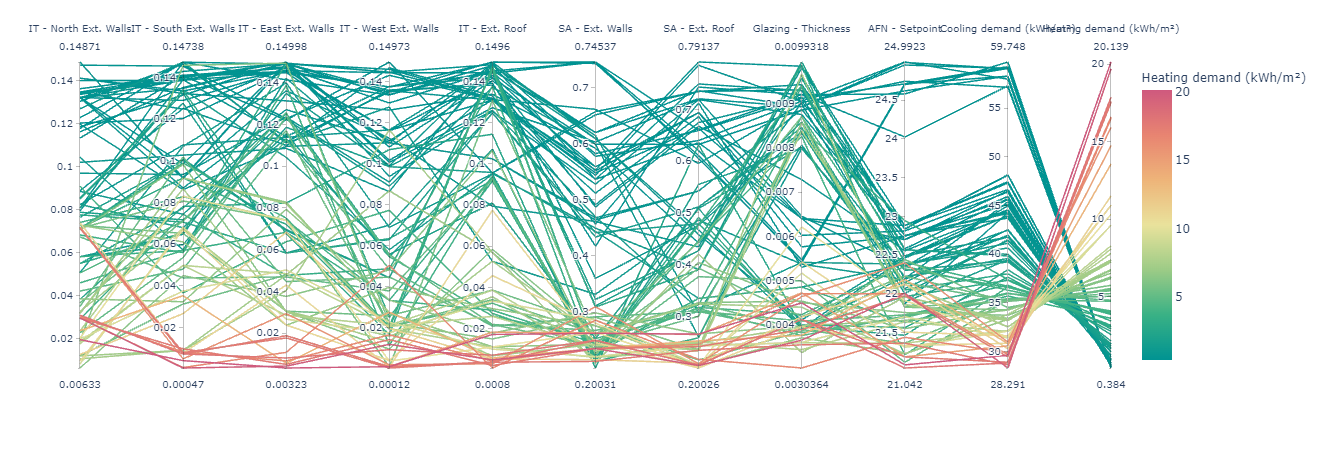

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["IT - North Ext. Walls","IT - South Ext. Walls","IT - East Ext. Walls","IT - West Ext. Walls","IT - Ext. Roof","SA - Ext. Walls","SA - Ext. Roof", "Glazing - Thickness", "AFN - Setpoint", "Cooling demand (kWh/m²)","Heating demand (kWh/m²)" ],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.029572,0.000471,0.004137,0.011684,0.004775,0.234976,0.204948,0.003664,22.006651,28.291308,19.697158,0,True
1,0.136270,0.140995,0.146975,0.129710,0.145200,0.745369,0.660159,0.009196,24.578916,59.748055,0.383937,0,True
2,0.030074,0.008143,0.006608,0.016324,0.004163,0.235401,0.245779,0.004713,22.000162,29.660543,16.480904,0,True
3,0.118483,0.131481,0.149980,0.110070,0.148820,0.577416,0.639633,0.009050,24.992292,57.979587,0.484012,0,True
4,0.148709,0.091330,0.149211,0.146155,0.131887,0.552946,0.791371,0.009837,22.882830,47.445433,0.495810,0,True
5,0.012596,0.026563,0.068285,0.019457,0.005116,0.215158,0.209511,0.004185,22.125254,30.267987,11.492714,0,True
6,0.019751,0.037398,0.050281,0.022515,0.009984,0.220506,0.242662,0.003614,21.704547,31.369131,9.605105,0,True
7,0.073857,0.007708,0.043015,0.000579,0.077509,0.245434,0.200260,0.003965,21.332049,30.830302,10.889246,0,True
8,0.071474,0.007882,0.017643,0.000121,0.003601,0.212119,0.234411,0.003559,21.362753,28.600751,17.563396,0,True
9,0.018489,0.049656,0.028543,0.020998,0.038652,0.231379,0.250352,0.003450,21.638297,32.041573,8.070679,0,True


In [11]:
results.to_csv('../results/h_envelope_rb_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
10,0.058114,0.056869,0.068317,0.033276,0.093949,0.226548,0.3347,0.00486,21.627859,35.692692,3.593439,0,True
